# MAG_COG_functional_annotations

Annotated MAGs with RAST, got .faa files from this process

Using COGclassifier: https://github.com/moshi4/COGclassifier

In [ ]:
##INSTALLATION
conda create --prefix /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/cogclassifier
conda activate /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/cogclassifier
conda install -c conda-forge -c bioconda cogclassifier

#download files needed, put in scratch /cog_db
cd /scratch4/workspace/nikea_ulrich_uml_edu-col_data/cog_db
wget https://ftp.ncbi.nih.gov/pub/COG/COG2024/data/cog-24.fun.tab
wget https://ftp.ncbi.nih.gov/pub/COG/COG2024/data/cog-24.def.tab
wget https://ftp.ncbi.nih.gov/pub/mmdb/cdd/cddid.tbl.gz
wget https://ftp.ncbi.nih.gov/pub/mmdb/cdd/little_endian/Cog_LE.tar.gz

In [ ]:
#trying with example ecoli.faa (worked!)
COGclassifier -i ecoli.faa -d ../cog_db/ -o ./ecoli_cogclassifier

In [ ]:
#create sample ID list
ls *.faa > MAGs.txt

In [ ]:
#!/bin/bash
#SBATCH -c 4  # Number of Cores per Task
#SBATCH --mem=5G  # Requested Memory
#SBATCH -p cpu,cpu-preempt  # Partition
#SBATCH -t 2:00:00  # Job time limit
#SBATCH --mail-type=ALL
#SBATCH -o /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/slurms/slurm-cogclassifier-%j.out  # %j = job ID

module load conda/latest
conda activate /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/cogclassifier

#parameters
MAGSPATH="/scratch4/workspace/nikea_ulrich_uml_edu-col_data/MAGs"
DB="/scratch4/workspace/nikea_ulrich_uml_edu-col_data/cog_db"
LIST="MAGs.txt"
OUT="/scratch4/workspace/nikea_ulrich_uml_edu-col_data/MAGs/cog_classifier"
mkdir -p $OUT

#run COGclassifier
while IFS= read -r SAMPLEID; do
COGclassifier -i $MAGSPATH/"${SAMPLEID}".faa -d $DB -o $OUT/"${SAMPLEID}"
 if [ $? -eq 0 ]; then
        echo "COGclassifier profile completed for sample: $SAMPLEID"
    else
        echo "COGclassifier encountered an error for sample: $SAMPLEID"
        exit 1
    fi 
done < "$MAGSPATH/${LIST}"

conda deactivate

#JOBID: 61592685
#BASH SCRIPT FILE: COL_cogclassifier.sh

did the last 2 MAGs separately when I got their annotations

In [ ]:
#copy all cog_count files into one directory
cd /scratch4/workspace/nikea_ulrich_uml_edu-col_data/MAGs/cog_classifier
for dir in */; do
    # Remove the trailing slash from the directory name variable
    dir_name="${dir%/}"
    
    # Define the target file you want to look for (change "target_file.txt" to your file name)
    target_file="${dir}cog_count.tsv"
    
    # Check if the file exists in that directory
    if [ -f "$target_file" ]; then
        # Extract the extension of the file
        ext="${target_file##*.}"
        
        # Copy the file out and rename it to the directory name
        cp "$target_file" "./cog_count_files/${dir_name}.${ext}"
    fi
done

Make sure using skbio kernel

#### DLAB

In [1]:
import pandas as pd

In [2]:
import os

In [3]:
os.chdir('/scratch4/workspace/nikea_ulrich_uml_edu-col_data/MAGs/cog_classifier/cog_count_files/dlab')

In [8]:
#something like this!
# Load the TSV files (specify the tab separator)
df1 = pd.read_csv('Afipia_broomeae_dlab_metabat2.44.tsv', sep='\t')
df2 = pd.read_csv('Aquimarina_sp.dlab_metabat2.7.tsv', sep='\t')
df3 = pd.read_csv('Aridibacter_sp.dlab_metabat2.74.tsv', sep='\t')
df4 = pd.read_csv('dlab_metabat2.22.tsv', sep='\t')
df5 = pd.read_csv('dlab_metabat2.54.tsv', sep='\t')
df6 = pd.read_csv('JAALKG01_sp.dlab_metabat2.73.tsv', sep='\t')
df7 = pd.read_csv('JAKSBE01_sp.dlab_maxbin2.015.tsv', sep='\t')
df8 = pd.read_csv('JAKSDE01_sp022360235_dlab_metabat2.38.tsv', sep='\t')
df9 = pd.read_csv('JANQNX01_sp.dlab_concoct.75.tsv', sep='\t')
df10 = pd.read_csv('Sphingomonas_sp017304125_dlab_metabat2.9.tsv', sep='\t')

# Merge on the specific column
merged_df = pd.merge(df1, df2, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_df1_df2.tsv', sep='\t', index=False)

In [9]:
# Merge on the specific column
merged_df = pd.merge(df3, df4, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_df3_df4.tsv', sep='\t', index=False)

In [10]:
# Merge on the specific column
merged_df = pd.merge(df5, df6, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_df5_df6.tsv', sep='\t', index=False)

In [11]:
# Merge on the specific column
merged_df = pd.merge(df7, df8, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_df7_df8.tsv', sep='\t', index=False)

In [12]:
# Merge on the specific column
merged_df = pd.merge(df9, df10, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_df9_df10.tsv', sep='\t', index=False)

then merged them with each other after adding their names to the count columns. there is probs a faster way to do this but here we are

In [14]:
cdf1 = pd.read_csv('dlab_df1_df2.tsv', sep='\t')
cdf2 = pd.read_csv('dlab_df3_df4.tsv', sep='\t')
cdf3 = pd.read_csv('dlab_df5_df6.tsv', sep='\t')
cdf4 = pd.read_csv('dlab_df7_df8.tsv', sep='\t')
cdf5 = pd.read_csv('dlab_df9_df10.tsv', sep='\t')

In [15]:
# Merge on the specific column set 1
merged_df = pd.merge(cdf1, cdf2, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_cdf1_cdf2.tsv', sep='\t', index=False)

# Merge on the specific column set 2
merged_df = pd.merge(cdf3, cdf4, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_cdf3_cdf4.tsv', sep='\t', index=False)

In [16]:
codf1 = pd.read_csv('dlab_cdf1_cdf2.tsv', sep='\t')
codf2 = pd.read_csv('dlab_cdf3_cdf4.tsv', sep='\t')

In [17]:
# Merge on the specific column set 2
merged_df = pd.merge(codf2, cdf5, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_codf2_cdf5.tsv', sep='\t', index=False)

In [18]:
codf3 = pd.read_csv('dlab_codf2_cdf5.tsv', sep='\t')

In [19]:
#final merge
merged_df = pd.merge(codf1, codf3, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_all_cog_counts.tsv', sep='\t', index=False)

#### MCAV

In [1]:
import pandas as pd

In [2]:
import os

In [3]:
os.chdir('/scratch4/workspace/nikea_ulrich_uml_edu-col_data/MAGs/cog_classifier/cog_count_files/mcav')

In [4]:
# Load the TSV files (specify the tab separator)
df1 = pd.read_csv('Aridibacter_sp.mcav_metabat2.3.tsv', sep='\t')
df2 = pd.read_csv('JASJDA01_sp.mcav_metabat2.24.tsv', sep='\t')
df3 = pd.read_csv('JAKSCL01_sp022360615_mcav_metabat2.9.tsv', sep='\t')
df4 = pd.read_csv('JBCBRR01_sp.mcav_metabat2.19.tsv', sep='\t')

# Merge on the specific column
merged_df = pd.merge(df1, df2, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_df1_df2.tsv', sep='\t', index=False)

# Merge on the specific column
merged_df = pd.merge(df3, df4, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_df3_df4.tsv', sep='\t', index=False)

In [5]:
cdf1 = pd.read_csv('dlab_df1_df2.tsv', sep='\t')
cdf2 = pd.read_csv('dlab_df3_df4.tsv', sep='\t')

# Merge on the specific column set 1
merged_df = pd.merge(cdf1, cdf2, on='LETTER', how='outer')

# Save to a new TSV file
merged_df.to_csv('dlab_cdf1_cdf2.tsv', sep='\t', index=False)

*didn't change dlab to mcav for efficiency purposes but don't worry I used the right files*

#### Dotplot to show abundances of COG categories across samples

In [1]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL"

In [2]:
#load libraries
library(ggplot2)
library(tidyverse)
library(vegan)
library(RColorBrewer)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute



In [2]:
setwd("/scratch4/workspace/nikea_ulrich_uml_edu-col_data/MAGs/cog_classifier/cog_count_files/dlab")

In [61]:
dlab_cogs <- read.csv("dlab_all_cog_table.csv", header=TRUE)

In [16]:
options(repr.plot.width=12, repr.plot.height=10)

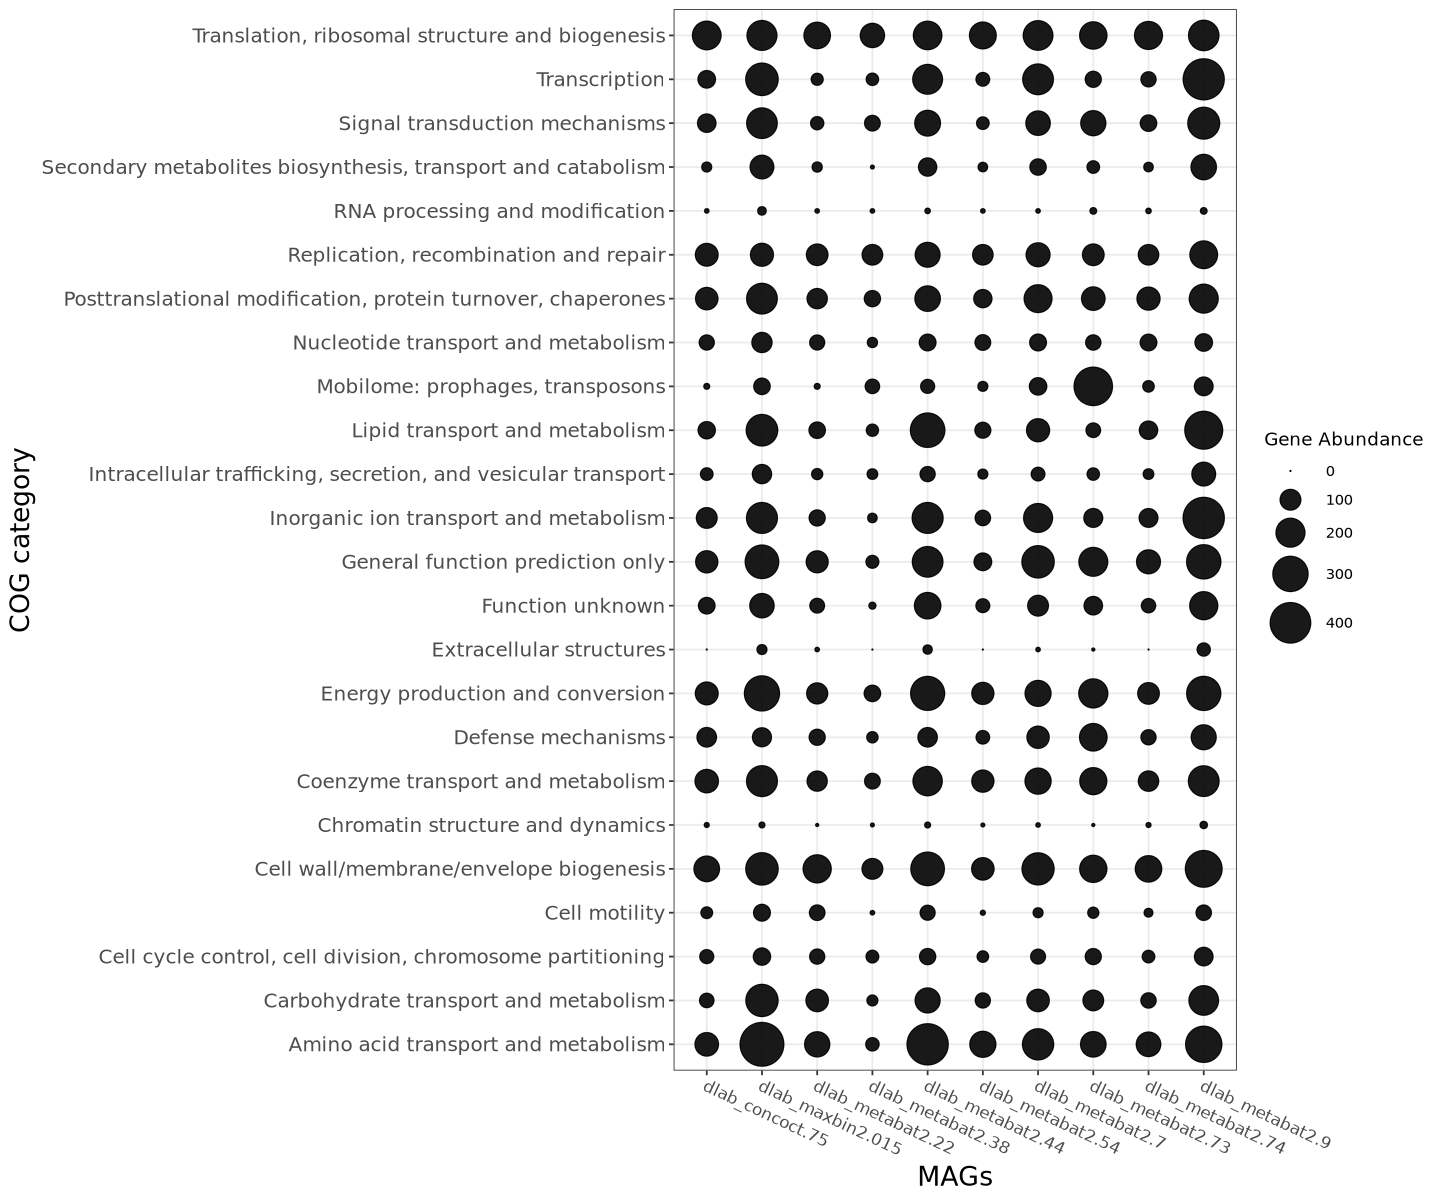

In [63]:
dlab_cogs %>% 
  gather(sample, value, dlab_metabat2.44:dlab_metabat2.9) %>%
  ggplot(aes(sample, COG_category, size = value)) + 
  geom_point(alpha = 0.9) +
  scale_size_area(max_size = 12) +
  theme_bw() +
  theme(axis.text.x = element_text(size = 10, angle=-25,hjust = 0, vjust = 1),
        axis.text.y = element_text(size = 12,angle = 0,vjust = 0.5),
        axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
        axis.title.y = element_text(size = 16))+
        labs(x = "MAGs", y = "COG category", size = "Gene Abundance")
        

Reformat data so that I can add total genes column and color by percentage

In [64]:
dlab_cogs_t2 <- read.csv("dlab_all_cogs_to_pivot.csv", header=TRUE)

In [73]:
dlab_table <- dlab_cogs_t2 %>%
    pivot_longer(-c(MAG, Total), names_to = "COG_category", values_to = c("Count"))
head(dlab_table)

MAG,Total,COG_category,Count
<chr>,<int>,<chr>,<int>
dlab_metabat2.44,3542,RNA.processing.and.modification,5
dlab_metabat2.44,3542,Chromatin.structure.and.dynamics,6
dlab_metabat2.44,3542,Energy.production.and.conversion,279
dlab_metabat2.44,3542,Cell.cycle.control..cell.division..chromosome.partitioning,59
dlab_metabat2.44,3542,Amino.acid.transport.and.metabolism,414
dlab_metabat2.44,3542,Nucleotide.transport.and.metabolism,63


In [8]:
library(stringr)
library(viridis)

Loading required package: viridisLite



In [87]:
#replace periods with spaces in COG_category column
dlab_table <- dlab_table %>%
  mutate(COG_category = str_replace_all(COG_category, fixed("."), " "))
head(dlab_table)

MAG,Total,COG_category,Count
<chr>,<int>,<chr>,<int>
dlab_metabat2.44,3542,RNA processing and modification,5
dlab_metabat2.44,3542,Chromatin structure and dynamics,6
dlab_metabat2.44,3542,Energy production and conversion,279
dlab_metabat2.44,3542,Cell cycle control cell division chromosome partitioning,59
dlab_metabat2.44,3542,Amino acid transport and metabolism,414
dlab_metabat2.44,3542,Nucleotide transport and metabolism,63


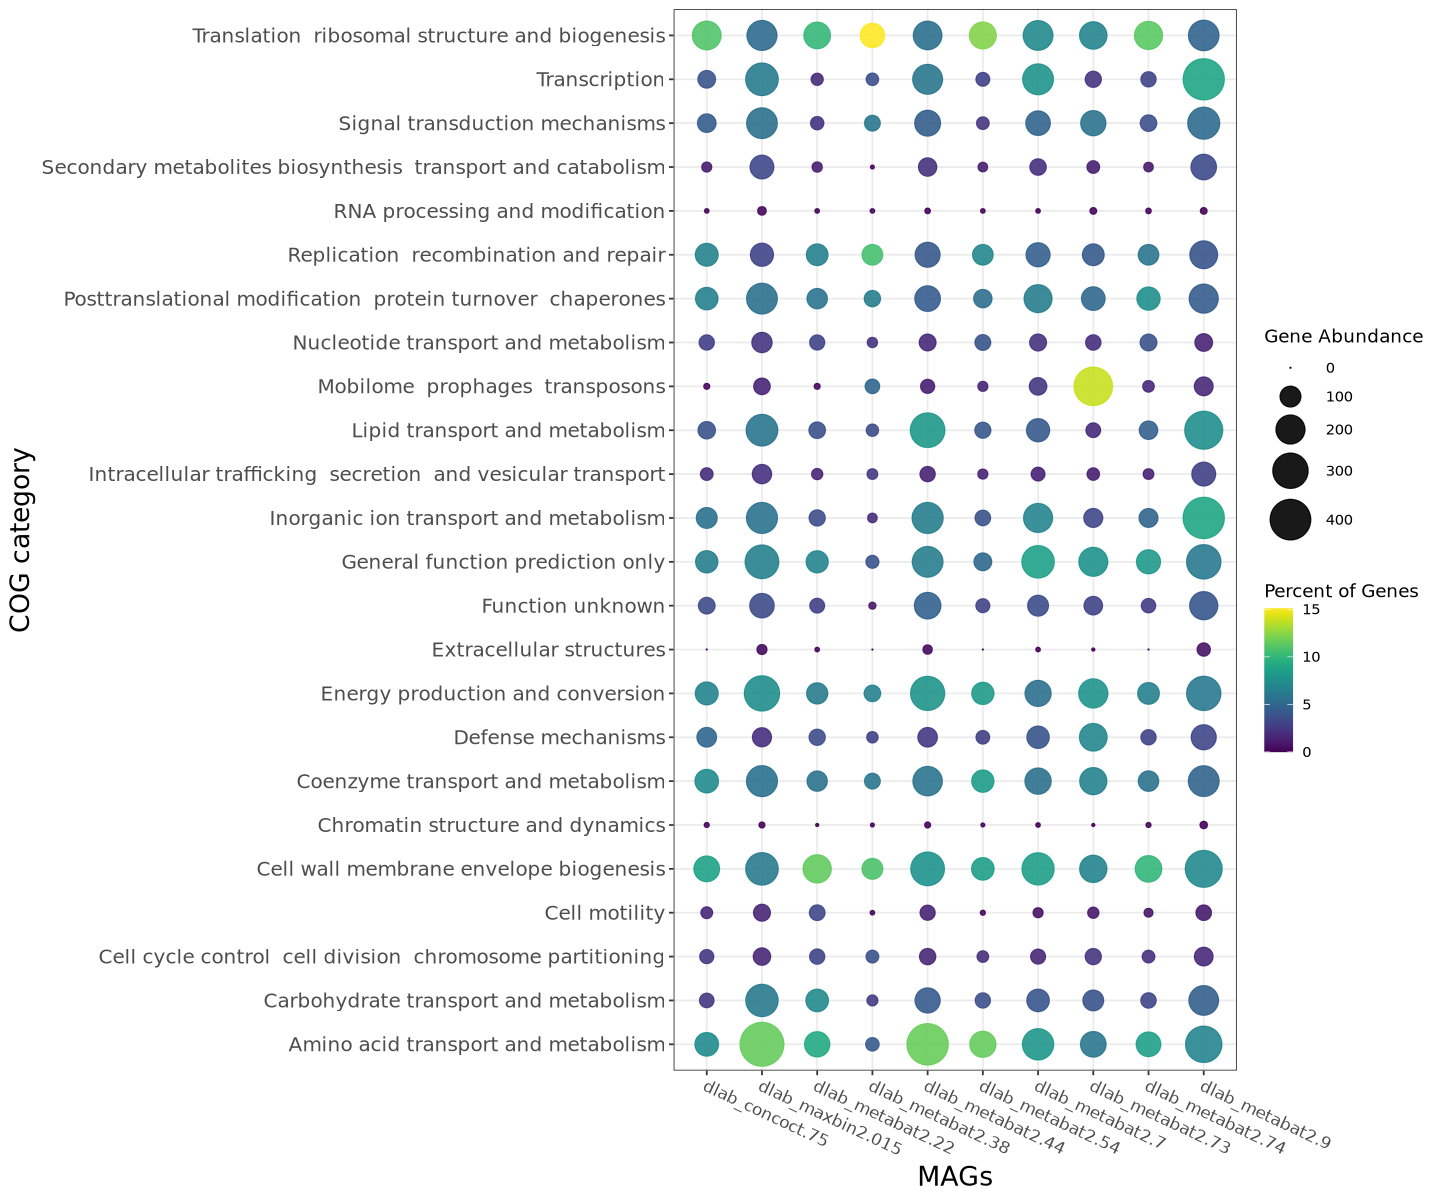

In [86]:
dlab_plot<- ggplot(data=dlab_table, aes(x=MAG, y=COG_category, size = Count, color=(Count/Total)*100)) + 
  geom_point(alpha = 0.9) +
  scale_size_area(max_size = 12) +
  scale_color_viridis()+
  theme_bw() +
  theme(axis.text.x = element_text(size = 10, angle=-25,hjust = 0, vjust = 1),
        axis.text.y = element_text(size = 12,angle = 0,vjust = 0.5),
        axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
        axis.title.y = element_text(size = 16))+
        labs(x = "MAGs", y = "COG category", size = "Gene Abundance", color= "Percent of Genes")
dlab_plot

In [88]:
ggsave(filename = "DLAB_mag_COGs.png", plot = dlab_plot, 
      width = 12,
      height = 10,
      units = "in",
      dpi = 300)

**notes to self** \
maybe add the ID to beginning of x label so we know more about the MAG \
could facet by what species coral each MAG is from, right now keeping separate \
pull out genes in specific COGs of interest (i.e. defense mechanisms)

In [ ]:
#now do mcav

In [10]:
setwd("/scratch4/workspace/nikea_ulrich_uml_edu-col_data/MAGs/cog_classifier/cog_count_files/mcav")

In [11]:
mcav_cogs <- read.csv("mcav_all_cogs_to_pivot.csv", header=TRUE)

Warning message in read.table(file = file, header = header, sep = sep, quote = quote, :
“incomplete final line found by readTableHeader on 'mcav_all_cogs_to_pivot.csv'”


In [12]:
head(mcav_cogs)

,MAG,RNA.processing.and.modification,Chromatin.structure.and.dynamics,Energy.production.and.conversion,Cell.cycle.control..cell.division..chromosome.partitioning,Amino.acid.transport.and.metabolism,Nucleotide.transport.and.metabolism,Carbohydrate.transport.and.metabolism,Coenzyme.transport.and.metabolism,Lipid.transport.and.metabolism,⋯,Inorganic.ion.transport.and.metabolism,Secondary.metabolites.biosynthesis..transport.and.catabolism,General.function.prediction.only,Function.unknown,Signal.transduction.mechanisms,Intracellular.trafficking..secretion..and.vesicular.transport,Defense.mechanisms,Extracellular.structures,Mobilome..prophages..transposons,Total
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,mcav_metabat2.3,5,4,105,36,145,62,50,91,78,⋯,107,18,101,43,59,24,46,0,72,1686
2,mcav_metabat2.24,8,8,321,46,206,78,151,237,84,⋯,145,101,307,125,327,101,104,1,324,3545
3,mcav_metabat2.9,9,4,215,37,355,68,131,174,175,⋯,200,73,196,118,144,50,56,21,11,2844
4,mcav_metabat2.19,2,0,17,7,33,12,1,3,4,⋯,14,1,31,4,20,11,3,0,48,505


In [13]:
mcav_table <- mcav_cogs %>%
    pivot_longer(-c(MAG, Total), names_to = "COG_category", values_to = c("Count"))
head(mcav_table)

MAG,Total,COG_category,Count
<chr>,<int>,<chr>,<int>
mcav_metabat2.3,1686,RNA.processing.and.modification,5
mcav_metabat2.3,1686,Chromatin.structure.and.dynamics,4
mcav_metabat2.3,1686,Energy.production.and.conversion,105
mcav_metabat2.3,1686,Cell.cycle.control..cell.division..chromosome.partitioning,36
mcav_metabat2.3,1686,Amino.acid.transport.and.metabolism,145
mcav_metabat2.3,1686,Nucleotide.transport.and.metabolism,62


In [14]:
#replace periods with spaces in COG_category column
mcav_table <- mcav_table %>%
  mutate(COG_category = str_replace_all(COG_category, fixed("."), " "))
head(mcav_table)

MAG,Total,COG_category,Count
<chr>,<int>,<chr>,<int>
mcav_metabat2.3,1686,RNA processing and modification,5
mcav_metabat2.3,1686,Chromatin structure and dynamics,4
mcav_metabat2.3,1686,Energy production and conversion,105
mcav_metabat2.3,1686,Cell cycle control cell division chromosome partitioning,36
mcav_metabat2.3,1686,Amino acid transport and metabolism,145
mcav_metabat2.3,1686,Nucleotide transport and metabolism,62


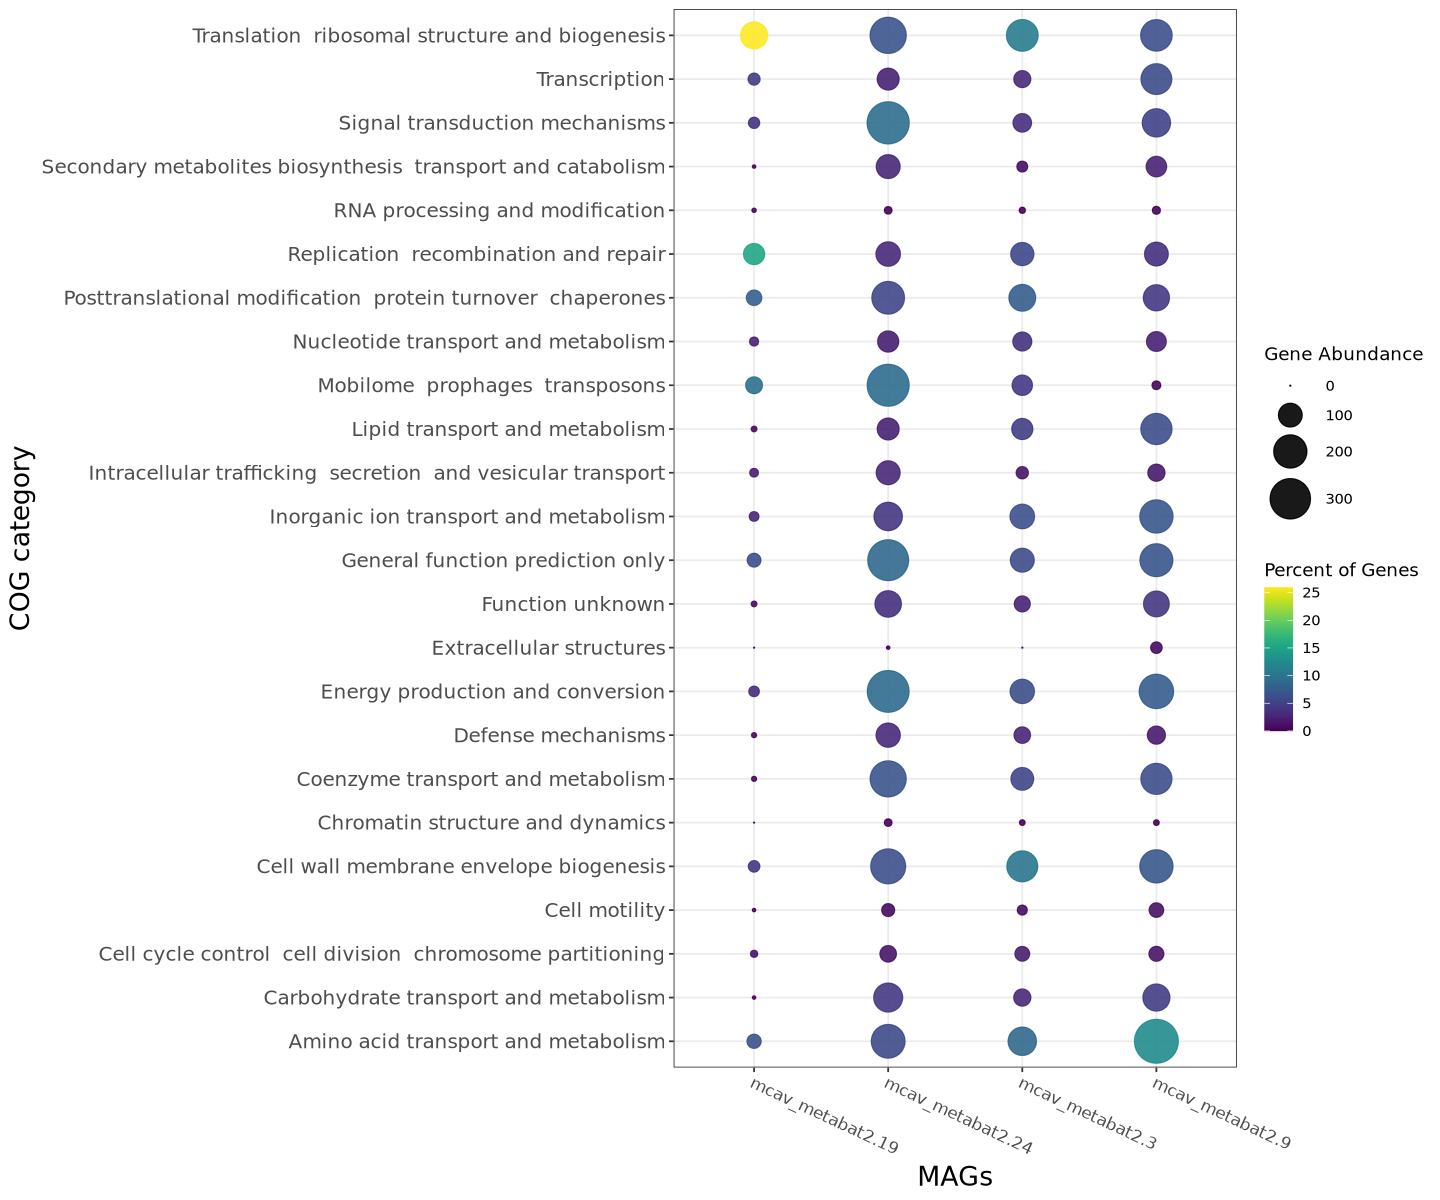

In [17]:
mcav_plot<- ggplot(data=mcav_table, aes(x=MAG, y=COG_category, size = Count, color=(Count/Total)*100)) + 
  geom_point(alpha = 0.9) +
  scale_size_area(max_size = 12) +
  scale_color_viridis()+
  theme_bw() +
  theme(axis.text.x = element_text(size = 10, angle=-25,hjust = 0, vjust = 1),
        axis.text.y = element_text(size = 12,angle = 0,vjust = 0.5),
        axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
        axis.title.y = element_text(size = 16))+
        labs(x = "MAGs", y = "COG category", size = "Gene Abundance", color= "Percent of Genes")
mcav_plot

In [18]:
ggsave(filename = "MCAV_mag_COGs.png", plot = mcav_plot, 
      width = 12,
      height = 10,
      units = "in",
      dpi = 300)